# 딥러닝 기초 수학 실습

## 1. 선형회귀 : 평균 제곱근 오차(RMSE; Root Mean Square Error)
### 1) 선형 회귀란? 
- 1) 임의의 직선(y = ax + b)을 그어 
- 2) 이에 대한 평균 제곱근 오차를 구하고 
- 3) 이 값을 가장 작게 만들어 주는 a와 b 값을 찾아가는 작업

### 2) 평균제곱근 오차(RMSE)를 이용한 선형회귀 수정 방법
#### 여러 개의 입력 값을 계산하는 방법
- 1) 임의의 선을 그리고 난 후 
- 2) 이 선이 얼마나 잘 그려졌는지를 평가하여 
- 3) 조금씩 수정해 가는 방법을 사용

#### 그려진 선의 오차를 평가하는 오차 평가 알고리즘이 필요
- 평균제곱근 오차(rmse; root mean square error)

#### 일단 그리고 조금씩 수정해 나가기 방식 
- 가설을 하나 세운 뒤 이 값이 주어진 요건을 충족하는지를 판단하여 조금씩 변화를 주고, 
- 이 변화가 긍정적이면 오차가 최소가 될 때까지 이 과정을 계속 반복하는 방법

#### 나중에 그린 선이 먼저 그린 선보다 더 좋은 지 나쁜지를 판단하기 위해 필요한 것은?
- 각 선의 오차를 계산 --> 오차가 작은 쪽으로 바꾸는 알고리즘이 필요

In [1]:
# 경고 무시
from warnings import filterwarnings
filterwarnings("ignore")

## 2. 평균제곱근(RMSE) 오차 실습

In [2]:
import numpy as np

# 기울기 a와 y 절편 b 정하기
ab = [3, 76]  # a = 3, b = 76

# x, y의 데이타 값 [공부시간, 점수]
data = [[2, 81], [4, 93], [6, 91], [8, 97]]
x = [i[0] for i in data] # x - 공부시간
y = [i[1] for i in data] # y - 점수

# y = ax+b에 a와 b 값을 대입하여 결과를 출력하는 함수
def predict(x):
    return ab[0]*x + ab[1]

# 평균제곱근(RMSE) 오차 함수
def rmse(p, a):
    return np.sqrt(((p - a)**2).mean())

# 평균제곱근(RMSE) 함수를 각 y값에 대입하여 최종값을 구하는 함수
def rmse_val(priedict_result, y):
    return rmse(np.array(predict_result), np.array(y))

# 예측값이 들어갈 빈 리스트
predict_result = []

# 모든 x값을 한번씩 대입하여 predict_result 리스트 완성
for i in range(len(x)):
    predict_result.append(predict(x[i]))
    print("공부한 시간 : %.f, 실제 점수 : %.f, 예측 점수 : %4.1f" % (x[i], y[i], predict(x[i])))
    
# 최종 RMSE 출력
print("RMSE 최종값 : " + str(rmse_val(predict_result, y)))


공부한 시간 : 2, 실제 점수 : 81, 예측 점수 : 82.0
공부한 시간 : 4, 실제 점수 : 93, 예측 점수 : 88.0
공부한 시간 : 6, 실제 점수 : 91, 예측 점수 : 94.0
공부한 시간 : 8, 실제 점수 : 97, 예측 점수 : 100.0
RMSE 최종값 : 3.3166247903554


### 중간 결론
- 기울기 a = 3, 절편 b = 76 --> 오차가 약 3.3166이라는 것을 알게 됨
- 이제 남은 것은 이 오차를 줄이면서 새로운 선을 긋는 것
- 이를 위해서는 a와 b의 값을 적절히 조절하면서 오차의 변화를 살펴보고, 
- 그 오차가 최소화되는 a와 b의 값을 구해야 함(미분 필요)
- 오차 수정하기 --> "경사하강법"

## 3. 오차 수정하기 : 경사 하강법

### 경사하강법(gradient decent)
- 오차의 변화에 따라 이차 함수 그래프를 만들고
- 적절한 학습률을 설정해 미분 값이 0인 지점을 구하는 것

### 1) 공부시간과 성적 그래프로 확인하기

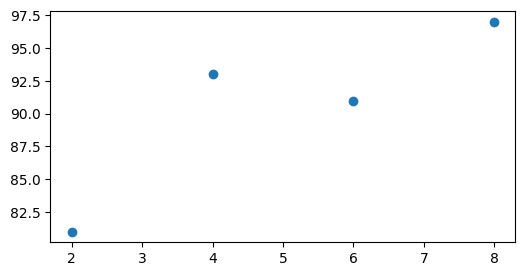

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 공부시간 x와 성적 y의 이중 리스트 생성 [[공부시간, 성적], ...]
data = [[2, 81], [4, 93], [6, 91], [8, 97]]
x = [i[0] for i in data] # 공부 시간
y = [i[1] for i in data] # 성적

# 그래프 그리기
plt.figure(figsize=(6,3))
plt.scatter(x, y)
plt.show()

### 2) 경사 하강법으로 기울기 a와 y 절편 b 찾기

<img src="./img/편미분.jpg" width=400 align=left>

In [4]:
# 리스트로 되어 있는 x와 y값을 넘파이 배열로 바꾸기
x_data = np.array(x)
y_data = np.array(y)

# 기울기 a와 절편 b의 값을 초기화 
a = 0
b = 0

# 학습률을 정합니다.
lr = 0.04 

# 몇 번 반복될지를 설정
epochs = 2000 

# 경사 하강법 시작
for i in range(epochs): # epoch 수 만큼 반복
    y_hat = a * x_data + b  # y를 구하는 식
    error = y_data - y_hat  # 오차를 구하는 식
    a_diff = -(1/len(x_data)) * sum(x_data * (error)) # 오차함수를 a로 편미분한 값 
    b_diff = -(1/len(x_data)) * sum(error)            # 오차함수를 b로 편미분한 값 
    a = a - lr * a_diff  # 학습률을 곱해 기존의 a값을 업데이트
    b = b - lr * b_diff  # 학습률을 곱해 기존의 b값을 업데이트
    if i % 100 == 0:    # 100번 반복될 때마다 현재의 a값, b값을 출력
        print("epoch=%.f, 기울기(a)=%.04f, 절편(b)=%.04f" % (i, a, b))
        #print("epoch=%.f, 기울기(a)=%.04f, 절편(b)=%.04f a미분값 : %.4f, b미분값 : %.4f" % (i, a, b, a_diff, b_diff))
        print('-'*100)

epoch=0, 기울기(a)=18.5600, 절편(b)=3.6200
----------------------------------------------------------------------------------------------------
epoch=100, 기울기(a)=8.9416, 절편(b)=39.3658
----------------------------------------------------------------------------------------------------
epoch=200, 기울기(a)=5.7649, 절편(b)=58.3229
----------------------------------------------------------------------------------------------------
epoch=300, 기울기(a)=4.1076, 절편(b)=68.2128
----------------------------------------------------------------------------------------------------
epoch=400, 기울기(a)=3.2430, 절편(b)=73.3723
----------------------------------------------------------------------------------------------------
epoch=500, 기울기(a)=2.7920, 절편(b)=76.0641
----------------------------------------------------------------------------------------------------
epoch=600, 기울기(a)=2.5567, 절편(b)=77.4683
----------------------------------------------------------------------------------------------------
epoch=700, 기울기(

#### 실행 결과 해석
- 에포크(Epoch) : 입력 값에 대해 몇 번이나 반복하여 실험했는지를 나타냄
- 평균 제곱근 오차(RMSE)의 변화와 기울기 a가 2.3에 수렴
- y 절편 b가 79에 수렴하는 과정을 볼 수 있음
- 시험성적 = 2.3`*`공부시간 + 79.0

### 3) 기울기와 절편을 이용한 회귀선 그리기

x_data = [2 4 6 8]
기울기(a)=2.3000, 절편(b)=78.9998
x_pred = [83.59988661 88.19994377 92.80000093 97.40005809]


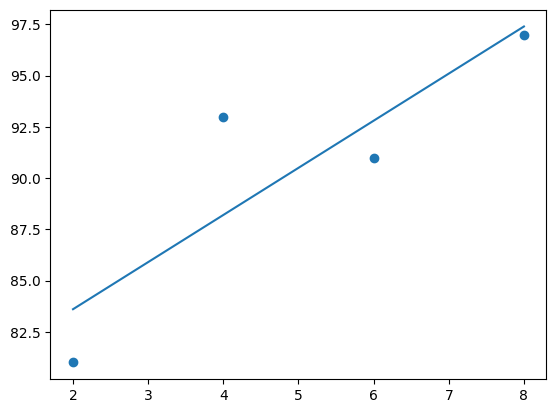

<Figure size 600x300 with 0 Axes>

In [5]:
# 앞서 구한 기울기와 절편을 이용해 그래프 그리기
import matplotlib.pyplot as plt

print("x_data =", x_data)
print("기울기(a)=%.04f, 절편(b)=%.04f" % (a, b))
y_pred = a * x_data + b
print("x_pred =", y_pred)

plt.scatter(x, y)
plt.plot([min(x_data), max(x_data)], [min(y_pred), max(y_pred)])
plt.figure(figsize=(6,3))
plt.show()

## 4. 다중선형회귀

### 1) 다중선형회귀 실습

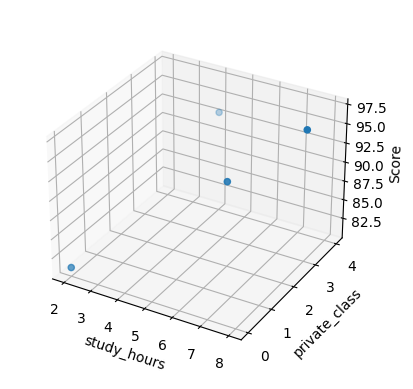

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

# 공부시간 X1, 과외시간 X2, 성적 Y의 리스트 생성 [[공부시간, 과외수업횟수, 성적], ...]
data = [[2, 0, 81], [4, 4, 93], [6, 2, 91], [8, 3, 97]]
x1 = [i[0] for i in data]   # 공부시간
x2 = [i[1] for i in data]   # 과외시간
y = [i[2] for i in data]    # 성적

#그래프로 확인(3차원)
ax = plt.axes(projection='3d')
ax.set_xlabel('study_hours')     # 공부시간
ax.set_ylabel('private_class')   # 과외시간
ax.set_zlabel('Score')           # 성적
ax.dist = 11 
ax.scatter(x1, x2, y)
plt.show()

### 2) 경사 하강법으로 기울기 a1, a2, y 절편 b 찾기

In [7]:
# 공부시간 X1, 과외시간 X2, 성적 Y의 리스트 생성 [[공부시간, 과외수업횟수, 성적], ...]
data = [[2, 0, 81], [4, 4, 93], [6, 2, 91], [8, 3, 97]]
x1 = [i[0] for i in data]   # 공부시간
x2 = [i[1] for i in data]   # 과외시간
y = [i[2] for i in data]    # 성적

# 리스트로 되어 있는 x1, x2, y값을 넘파이 배열로 변경
# (인덱스를 주어 하나씩 불러와 계산이 가능해 지도록 하기 위함)
x1_data = np.array(x1)
x2_data = np.array(x2)
y_data = np.array(y)

# 기울기 a와 절편 b의 값을 초기화
a1 = 0
a2 = 0
b = 0

# 학습률
lr = 0.04 

# 몇 번 반복될지를 설정
epochs = 2000

#경사 하강법 시작
for i in range(epochs): # epoch 수 만큼 반복
    y_pred = a1 * x1_data + a2 * x2_data + b  # y를 구하는 식
    error = y_data - y_pred  # 오차를 구하는 식
    a1_diff = -(1/len(x1_data)) * sum(x1_data * (error)) # 오차함수를 a1로 미분한 값 
    a2_diff = -(1/len(x2_data)) * sum(x2_data * (error)) # 오차함수를 a2로 미분한 값 
    b_new = -(1/len(x1_data)) * sum(y_data - y_pred)  # 오차함수를 b로 미분한 값 
    a1 = a1 - lr * a1_diff  # 학습률을 곱해 기존의 a1값을 업데이트
    a2 = a2 - lr * a2_diff  # 학습률을 곱해 기존의 a2값을 업데이트
    b = b - lr * b_new  # 학습률을 곱해 기존의 b값을 업데이트
    if i % 100 == 0:    # 100번 반복될 때마다 현재의 a1, a2, b값을 출력
        print("epoch=%.f, 기울기1=%.04f, 기울기2=%.04f, 절편=%.04f" % (i, a1, a2, b))
        print('-'*100)

epoch=0, 기울기1=18.5600, 기울기2=8.4500, 절편=3.6200
----------------------------------------------------------------------------------------------------
epoch=100, 기울기1=7.2994, 기울기2=4.2867, 절편=38.0427
----------------------------------------------------------------------------------------------------
epoch=200, 기울기1=4.5683, 기울기2=3.3451, 절편=56.7901
----------------------------------------------------------------------------------------------------
epoch=300, 기울기1=3.1235, 기울기2=2.8463, 절편=66.7100
----------------------------------------------------------------------------------------------------
epoch=400, 기울기1=2.3591, 기울기2=2.5823, 절편=71.9589
----------------------------------------------------------------------------------------------------
epoch=500, 기울기1=1.9546, 기울기2=2.4427, 절편=74.7362
----------------------------------------------------------------------------------------------------
epoch=600, 기울기1=1.7405, 기울기2=2.3688, 절편=76.2058
------------------------------------------------------------

- 시험성적 = 1.5`*`공부시간 + 2.2857`*`과외수업횟수 + 77.8571

### 3) 다중 선형회귀 3D로 보기 - 예측 평면

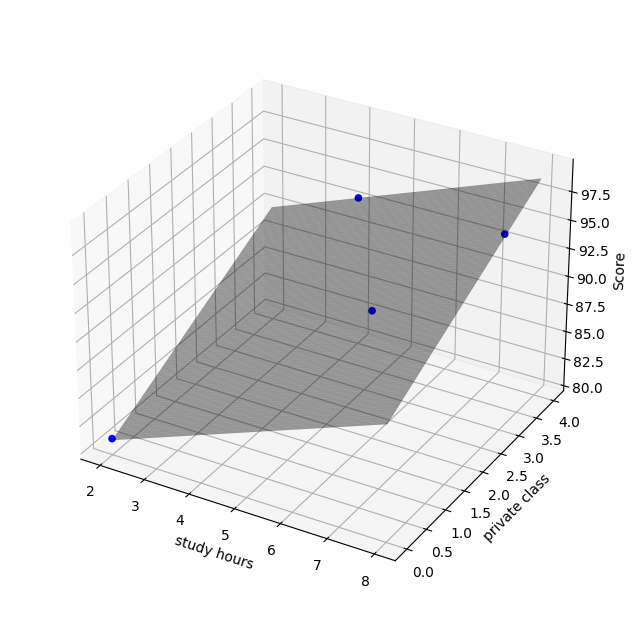

In [9]:
#다중 선형회귀 3D로 보기 - 예측 평면
import statsmodels.api as statm
import statsmodels.formula.api as statfa

X = [i[0:2] for i in data]
y = [i[2] for i in data]

X_1=statm.add_constant(X)
results=statm.OLS(y,X_1).fit()

hour_class=pd.DataFrame(X,columns=['study_hours','private_class'])
hour_class['Score']=pd.Series(y)

model = statfa.ols(formula='Score ~ study_hours + private_class', data=hour_class)

results_formula = model.fit()

a, b = np.meshgrid(np.linspace(hour_class.study_hours.min(),hour_class.study_hours.max(),100),
                   np.linspace(hour_class.private_class.min(),hour_class.private_class.max(),100))

X_ax = pd.DataFrame({'study_hours': a.ravel(), 'private_class': b.ravel()})
fittedY=results_formula.predict(exog=X_ax)

fig = plt.figure(figsize=(10,8))
graph = fig.add_subplot(111, projection='3d')

graph.scatter(hour_class['study_hours'],hour_class['private_class'],hour_class['Score'],
              c='blue',marker='o', alpha=1)
graph.plot_surface(a,b,fittedY.values.reshape(a.shape),
                   rstride=1, cstride=1, color='none', alpha=0.4)
graph.set_xlabel('study hours')
graph.set_ylabel('private class')
graph.set_zlabel('Score')
graph.dist = 11

plt.show()

- 1차원 예측 직선이 3차원 ‘예측 평면’으로 바뀌었음
- 과외 수업 횟수라는 새로운 변수가 추가되면서 1차원 직선에서만 움직이던 예측 결과가 
- 더 넓은 평면 범위 안에서 움직이게 되었음 => 좀 더 정밀한 예측을 할 수 있게 됨